In [46]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Connect to SQL Database

I've now added in the new tables containig the user's playlists and tracks.

In [47]:
# Connect to SQLite database
conn = sqlite3.connect("spotify_dataset.db")
cursor = conn.cursor()

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Fetch and print table names
tables = cursor.fetchall()
print("Tables in database:", tables)

Tables in database: [('user_playlists',), ('user_tracks',), ('spotify_tracks',)]


In [48]:
# Load dataset from SQLite
with sqlite3.connect("spotify_dataset.db") as conn:
    df_spotify_tracks = pd.read_sql_query("SELECT * FROM spotify_tracks;", conn)
    df_user_playlists = pd.read_sql_query("SELECT * FROM user_playlists;", conn)
    df_user_tracks = pd.read_sql_query("SELECT * FROM user_tracks;", conn)

In [49]:
df_spotify_tracks.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [50]:
df_user_playlists.head()

,id,href,description,name,owner_id,owner_display_name,tracks_href
0,1rHNyjILyZMYPqtUBrK6aa,https://api.spotify.com/v1/playlists/1rHNyjILy...,,Another Indie Playlist,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/1rHNyjILy...
1,4VrgDdNjljYe5f9ftLooXd,https://api.spotify.com/v1/playlists/4VrgDdNjl...,Playlist of similar songs based on Inside Out ...,Sad Sad Sad,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/4VrgDdNjl...
2,1yI15ngEZ2Yb5OKY409sQ3,https://api.spotify.com/v1/playlists/1yI15ngEZ...,This playlist was created by https:&#x2F;&#x2F...,Need a beat and some sad lyrics,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/1yI15ngEZ...
3,0qANIO5qxX93MV2ZfAS30h,https://api.spotify.com/v1/playlists/0qANIO5qx...,Please add the top five songs from your 2024 S...,W25 NSDC Team Playlist!,315qy5gce4c4gy2gl4u27w2ru5wm,Izzy,https://api.spotify.com/v1/playlists/0qANIO5qx...
4,7rmHlfiTAr6x8OgtjoFy3P,https://api.spotify.com/v1/playlists/7rmHlfiTA...,,Slow Pulp,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/7rmHlfiTA...


In [51]:
df_user_tracks.head()

,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,1rHNyjILyZMYPqtUBrK6aa,0svqVl7FSyjewup47iNOGz,0.0,1LNCdy3xZoibzDh0WllxHY,"[{""external_urls"": {""spotify"": ""https://open.s...",241290.0,https://api.spotify.com/v1/tracks/0svqVl7FSyje...,Magpie,47.0
1,1rHNyjILyZMYPqtUBrK6aa,4E5N0mYyYFf0QZs3XDeSIj,0.0,60EzsIzS77S9MWHT0Tm37s,"[{""external_urls"": {""spotify"": ""https://open.s...",173000.0,https://api.spotify.com/v1/tracks/4E5N0mYyYFf0...,Summer's Over,63.0
2,1rHNyjILyZMYPqtUBrK6aa,3aI2wWEeNmtYDvsAyJahyi,0.0,2GGqnsXKyCzNzlRql3QusN,"[{""external_urls"": {""spotify"": ""https://open.s...",201000.0,https://api.spotify.com/v1/tracks/3aI2wWEeNmtY...,Next Exit,62.0
3,1rHNyjILyZMYPqtUBrK6aa,6YVajR33kCWLhWpMVD8AGD,0.0,64SX9Efb2JGW3rJFE1ZddJ,"[{""external_urls"": {""spotify"": ""https://open.s...",187692.0,https://api.spotify.com/v1/tracks/6YVajR33kCWL...,Calling After Me,69.0
4,1rHNyjILyZMYPqtUBrK6aa,40iocOzytrqaRn5RbGPDNp,0.0,4uNgt1uQs6wZRm4giB3shX,"[{""external_urls"": {""spotify"": ""https://open.s...",208453.0,https://api.spotify.com/v1/tracks/40iocOzytrqa...,Cherry Flavoured,60.0


I checked to see if there are any duplicate rows in each df, if so I removed them and reset the df indexing.

In [52]:
# Count duplicated rows based on track_name and artists
duplicated_rows = df_spotify_tracks.duplicated(subset=['track_name', 'artists']).sum()

if duplicated_rows == 0:
    print('There are 0 duplicate rows based on song name and artist.')
else:
    print(f'There are {duplicated_rows} duplicate rows based on song name and artist. Dropping them now...')
    
    # Drop duplicates based on track_name and artists, keeping the first occurrence
    df_spotify_tracks = df_spotify_tracks.drop_duplicates(subset=['track_name', 'artists'], keep='first')
    # Rest the index of rows
    df_spotify_tracks = df_spotify_tracks.reset_index(drop=True)

    print(f'After dropping duplicates, there are {df_spotify_tracks.shape[0]} rows left.')


There are 32656 duplicate rows based on song name and artist. Dropping them now...
After dropping duplicates, there are 81344 rows left.


In [53]:
# Count duplicated rows based on track_name and artists
duplicated_rows = df_user_playlists.duplicated(subset=['name', 'description']).sum()

if duplicated_rows == 0:
    print('There are 0 duplicate rows based on playlist name and description.')
else:
    print(f'There are {duplicated_rows} duplicate rows based on playlist name and description. Dropping them now...')
    
    # Drop duplicates based on track_name and artists, keeping the first occurrence
    df_user_playlists = df_user_playlists.drop_duplicates(subset=['name', 'description'], keep='first')
    # Rest the index of rows
    df_user_playlists = df_user_playlists.reset_index(drop=True)

    print(f'After dropping duplicates, there are {df_user_playlists.shape[0]} rows left.')

There are 0 duplicate rows based on playllist name and description.


In [54]:
# Count duplicated rows based on track_name and artists
duplicated_rows = df_user_tracks.duplicated(subset=['track_name', 'track_popularity']).sum()

if duplicated_rows == 0:
    print('There are 0 duplicate rows based on song name and popularity.')
else:
    print(f'There are {duplicated_rows} duplicate rows based on song name and popularity. Dropping them now...')
    
    # Drop duplicates based on track_name and artists, keeping the first occurrence
    df_user_tracks = df_user_tracks.drop_duplicates(subset=['track_name', 'track_popularity'], keep='first')
    # Rest the index of rows
    df_user_tracks = df_user_tracks.reset_index(drop=True)

    print(f'After dropping duplicates, there are {df_user_tracks.shape[0]} rows left.')

There are 399 duplicate rows based on song name and popularity. Dropping them now...
After dropping duplicates, there are 2256 rows left.


Next I created a new df which contains all the user's songs that our kaggle dataset already has, so we can use those song metrics.

In [55]:
df_all_tracks = pd.DataFrame()
print(len(df_all_tracks))

for i in range(len(df_user_tracks)):
    value = df_user_tracks.loc[i, 'track_name']
    if value in df_spotify_tracks['track_name'].values:
        result = df_spotify_tracks.loc[df_spotify_tracks['track_name'] == value]
        df_all_tracks = pd.concat([df_all_tracks, result], ignore_index=True)
    
df_all_tracks

0


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,40iocOzytrqaRn5RbGPDNp,The Neighbourhood,Chip Chrome & The Mono-Tones,Cherry Flavoured,68,208453,0,0.6170,0.57400,6,-9.768,1,0.0276,0.23000,0.010500,0.0983,0.3960,91.769,4,alt-rock
1,2RJfK2pOvGpnxC255YOy5k,Paramore,After Laughter,Rose-Colored Boy,66,212853,0,0.7680,0.82600,5,-4.904,1,0.0335,0.00199,0.000374,0.0310,0.9260,114.997,4,emo
2,1M8OAc4NnD5GFMUiqjebaS,Flower Face,Baby Teeth,Baby Teeth,53,281843,0,0.2140,0.36700,6,-10.858,0,0.0321,0.84400,0.018100,0.1880,0.1750,79.854,4,ambient
3,6DpDUsVgeAGSO82NgDKxFM,Ethan Dufault,What If,California,47,201651,0,0.6090,0.65900,9,-6.943,1,0.0510,0.14300,0.000038,0.0713,0.3090,75.215,4,chill
4,0td8QgmgwUwlbk58VKf6Fl,ill Nicky;Vibes Only,California,California,39,171700,1,0.6110,0.80400,8,-5.021,1,0.1550,0.21700,0.000000,0.3060,0.6020,177.929,3,sad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1817,29S6PLRccSCyKozzwIik0J,Philip Glass;Valentina Lisitsa,Valentina Lisitsa Plays Philip Glass,The Truman Show: Truman Sleeps - Short Version,52,160453,0,0.2660,0.00361,8,-29.735,1,0.0520,0.99500,0.925000,0.0723,0.0631,94.861,4,ambient
1818,3LsRjtoQCTUN1nDVUVmxGT,Binaural Beats Brainwave Entrainment;Relaxing ...,35 Simply Soothing Rain Sounds for Restful Sleep,Rain Drops,34,110733,0,0.2120,0.99000,11,-20.566,0,0.0497,0.14900,0.997000,0.9580,0.0138,89.603,4,sleep
1819,3pajXCqOSkwgTIBXZEauQD,Tobias Berntsson,Fields Of Gold,Fields Of Gold,53,204051,0,0.5900,0.15400,2,-14.056,1,0.0736,0.97700,0.923000,0.1100,0.2950,175.735,4,guitar
1820,6c7uYlmHJtZPnenPjqG7Ir,Joep Beving,Solipsism,Sleeping Lotus,61,152000,0,0.3120,0.02680,7,-26.537,0,0.0369,0.99400,0.885000,0.1070,0.1880,68.524,4,ambient


In [56]:
df_all_tracks.loc[0]

track_id                  40iocOzytrqaRn5RbGPDNp
artists                        The Neighbourhood
album_name          Chip Chrome & The Mono-Tones
track_name                      Cherry Flavoured
popularity                                    68
duration_ms                               208453
explicit                                       0
danceability                               0.617
energy                                     0.574
key                                            6
loudness                                  -9.768
mode                                           1
speechiness                               0.0276
acousticness                                0.23
instrumentalness                          0.0105
liveness                                  0.0983
valence                                    0.396
tempo                                     91.769
time_signature                                 4
track_genre                             alt-rock
Name: 0, dtype: obje

Now it is no longer necessary for me to use the test data I created previously. 

## Create Test Data User Playlist

From our EDA, we learned which song metrics were highly correlated. Out of those I chose to work with 'loudness' and 'energy' to create a sample playlist of songs while we work on collecting more data.

In [57]:
# Select relevant features
features = ['loudness', 'energy']
df_selected = df_spotify_tracks[features]

In [58]:
""" 
Fit k-NN model, want to choose 30 songs for playlist so set n_neighbors to 30
"""
knn = NearestNeighbors(n_neighbors=30, metric='euclidean')
knn.fit(df_selected[features])

NearestNeighbors(metric='euclidean', n_neighbors=30)

In [59]:

def create_similar_playlist(reference_song, n=300):
    """Function to recommend similar songs
    Args:
        reference_song: db with one row containing the correlating metrics
        n : number of songs we want in our playlist

    Returns:
        recommended_tracks: db full of n songs with similar quantitvate features
    """
    # Extract energy & danceability of reference song
    ref_features = reference_song[features].values.reshape(1, -1)
    
    # Scale the reference song using the same scaler
    ref_scaled = scaler.transform(ref_features)
    
    # Find nearest neighbors
    distances, indices = knn.kneighbors(ref_scaled, n_neighbors=n)
    
    # Get recommended songs
    recommended_tracks = df_spotify_tracks.iloc[indices[0]]
    
    return recommended_tracks

Choose a random song to base the playlist off of

In [60]:
# Example: Choose a random seed song
reference_song = df_spotify_tracks.sample(1)  # Pick a random song
reference_song[['track_name', 'artists', 'loudness', 'energy', 'track_genre']]

,track_name,artists,loudness,energy,track_genre
46375,eliza,Jaleh Negari,-11.85,0.823,iranian


A spotify user will generally have many songs saved in their playlists, so I chose to have about 300 songs in this playlist. 

In [61]:
""" Generate a playlist of 300 generally similar songs, showing their correlated features, name, and genre """

playlist = create_similar_playlist(reference_song)
playlist[['track_id','track_name', 'artists', 'loudness', 'energy', 'track_genre']]

c:\Users\avajt\anaconda3\envs\PIC16B-25W\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\avajt\anaconda3\envs\PIC16B-25W\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,track_id,track_name,artists,loudness,energy,track_genre
8507,15ymCBGBgIGXLPNKMbA8k1,Top Ranking - Upgrade & T>I Remix,Ed Solo;Deekline;Upgrade (UK);T.I,-0.564,0.829,breakbeat
30532,1qHOuyguj3oPBkd6MTnEO3,Donos da Capital,Mc Kevin;MC Ryan SP;MC GP;Mc Lele JP;Mc IG;Dj ...,-0.730,0.782,funk
46046,1wkE3OwkzpEvf9CCxturAp,Despotism,Najand,-0.487,0.687,iranian
51912,2TDyyEBasw10wu5Uh94bR1,PUNTO 40,Rauw Alejandro;Baby Rasta,-0.722,0.826,latino
23864,4o7Rszx7VVCzrCr1RPlPot,Behemoth,SVDDEN DEATH,-0.595,0.893,dub
...,...,...,...,...,...,...
23192,7iJPTFkKt6DHZwKMBoCMC2,The Light,Annix;Simula,-1.078,0.964,drum-and-bass
48481,6EzZn96uOc9JsVGNRpx06n,うっせぇわ,Ado,-1.072,0.978,j-pop
47916,3zlbr5FcpOzvKy3Ih6PN9O,放課後ゲタ箱ロッケンロールMX,Shiritsu Ebisu Chugaku,-1.065,0.995,j-idol
44284,0nLLGNy0tQBuXszpbmKbSR,Tumse Bhi Zyada - Lofi,Emrose Percussion,-1.121,0.588,indian


## Get Playlist Recommendation

In [62]:
# Select relevant numerical features from our user's songs
features = ['danceability', 'energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'loudness']
df_users_filtered = df_all_tracks[features]

In [69]:
# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_users_filtered, df_users_filtered, test_size=0.2, random_state=42)

Want to fine tune the KNN model to ensure we are choosing the best parameters.

In [70]:
def tune_knn(X_train, X_test, k_values=range(1, 101)):
    """ Function to find the best k value for KNN model
    """
    best_k = None
    best_score = float('inf')  # Lower score is better
    scores = []

    for k in k_values:
        knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
        knn.fit(X_train)
        
        # Find distances to test points
        distances, _ = knn.kneighbors(X_test, n_neighbors=k)
        
        # Compute Mean Squared Error (MSE)
        mse = np.mean(distances**2)
        scores.append((k, mse))
        
        # Track best k
        if mse < best_score:
            best_score = mse
            best_k = k
    
    return best_k, scores

In [71]:
# Find the best k value
best_k, scores = tune_knn(X_train, X_test)
print(f"Optimal number of neighbors: {best_k}")

Optimal number of neighbors: 1


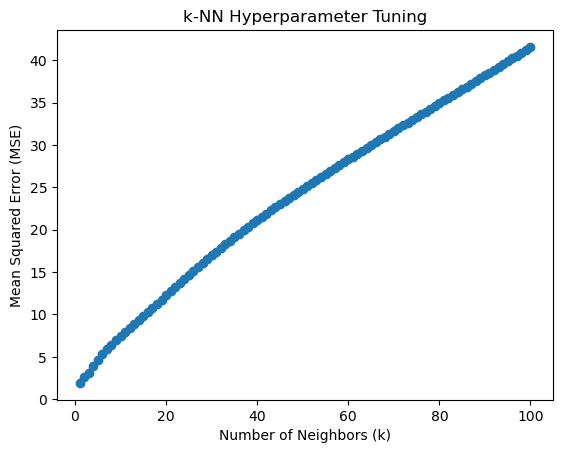

In [72]:
# Plot results
import matplotlib.pyplot as plt

k_values, mse_scores = zip(*scores)
plt.plot(k_values, mse_scores, marker='o', linestyle='-')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("k-NN Hyperparameter Tuning")
plt.show()

There are possible signs of overfitting since the best n_neighbor is 1, and the MSE scores are so accurate.

In [73]:
# Fit k-NN model with 7 features
knn = NearestNeighbors(n_neighbors=best_k, metric='euclidean')
knn.fit(df_users_filtered[features])

NearestNeighbors(metric='euclidean', n_neighbors=1)

We can now create a playlist based on the user's overall tracks. 

In [77]:
def recommend_songs(user_songs, genre=None, n=30):
    """ Function to recommend songs based on playlist
    Args: 
        user_songs: db full of playlists (rows must be >= n)
        genre: string, optional, genre provided by user to group tracks
        n: number of songs being recommended

    Returns:
        recommended_tracks: db which contains the n many recommended songs
    """
    
    # Filter dataset by genre if specified
    if genre:
        df_spot_filtered = df_spotify_tracks[df_spotify_tracks['track_genre'].str.lower() == genre.lower()]
        if df_spot_filtered.empty:
            print(f"Warning: No songs found for genre '{genre}'. Using all genres instead.")
            df_spot_filtered = df_spotify_tracks  # Fall back to all songs
    else:
        df_spot_filtered = df_spotify_tracks  # Use all genres if none specified

    # Ensure `n` does not exceed the number of available songs in the dataset
    max_neighbors = min(n, len(df_spot_filtered))  

    # Ensure `user_songs` has enough entries
    num_user_songs = len(user_songs)
    if num_user_songs < max_neighbors:
        print(f"Warning: User provided only {num_user_songs} songs. Adjusting neighbors to {num_user_songs}.")
        max_neighbors = num_user_songs

    # Create and scale the users songs with the given features
    scaler = StandardScaler()
    user_songs_scaled = scaler.fit_transform(user_songs[features])

     # Fit a k-NN model specifically for the filtered dataset
    knn_filtered = NearestNeighbors(n_neighbors=max_neighbors, metric='euclidean')
    knn_filtered.fit(df_spot_filtered[features])

    # Find nearest neighbors
    distances, indices = knn_filtered.kneighbors(user_songs_scaled, n_neighbors=max_neighbors)

    # Get recommended tracks from the filtered dataset
    recommended_tracks = df_spot_filtered.iloc[indices[0]]

    return recommended_tracks[['track_name', 'artists', 'track_genre', 'loudness', 'danceability', 'energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'valence']]


In [78]:

recommendations = recommend_songs(df_users_filtered, genre='indie')
recommendations

c:\Users\avajt\anaconda3\envs\PIC16B-25W\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,track_name,artists,track_genre,loudness,danceability,energy,tempo,speechiness,acousticness,instrumentalness,valence
44963,Could I Love You Any More (feat. Jason Mraz),Reneé Dominique;Jason Mraz,indie,-8.001,0.288,0.371,52.572,0.0386,0.66600,0.000000,0.197
44930,Mellow,Rohit Shakya;Sajjan Raj Vaidya,indie,-4.912,0.695,0.780,74.978,0.0514,0.11000,0.000143,0.604
44903,Maya,Chowraasta,indie,-5.612,0.585,0.325,75.032,0.0972,0.27900,0.000000,0.250
44955,Ghuroor,Izzchughtai;Abdul Hannan,indie,-13.000,0.392,0.331,74.824,0.1280,0.73700,0.000002,0.260
44865,I Love You So,The Walters,indie,-4.891,0.575,0.648,75.977,0.0358,0.58300,0.000000,0.466
44943,Somos Instantes,Caloncho,indie,-13.572,0.797,0.403,74.997,0.1050,0.77600,0.340000,0.664
44935,I Hear a Symphony,Cody Fry,indie,-8.542,0.197,0.247,75.787,0.0306,0.93400,0.016300,0.407
44864,Ra Ra Reddy I Am Ready,Lipsika;Aditya Iyengar,indie,-7.528,0.738,0.903,78.971,0.2530,0.38300,0.010900,0.699
44901,Young,Vacations,indie,-4.065,0.498,0.810,79.935,0.0263,0.00392,0.007170,0.594
44917,Rangarattinam,Tenma;M.S Krsna;Gana Muthu;Sangita Santhosham;...,indie,-6.439,0.738,0.758,82.482,0.1300,0.27300,0.000072,0.840


<Axes: title={'center': 'Song Genre Scatterplot'}, xlabel='loudness', ylabel='energy'>

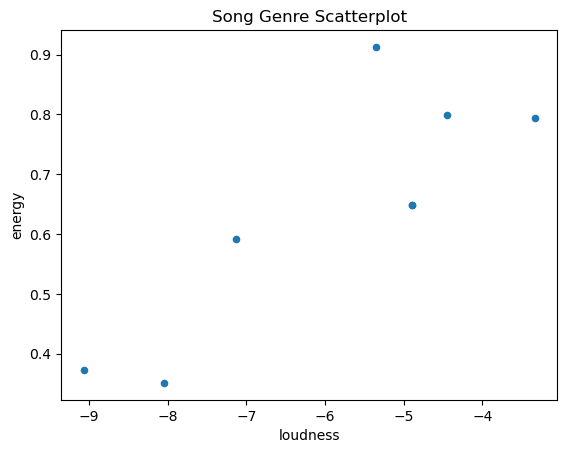

In [81]:
# Filter for the specific genre

genre_data = df_all_tracks[df_all_tracks['track_genre'] == 'indie']  


# Create scatter plot with 'runtime' on x-axis and 'rating' on y-axis

genre_data.plot.scatter(x='loudness', y='energy', title='Song Genre Scatterplot') 

<Axes: title={'center': 'Song Genre Scatterplot'}, xlabel='loudness', ylabel='energy'>

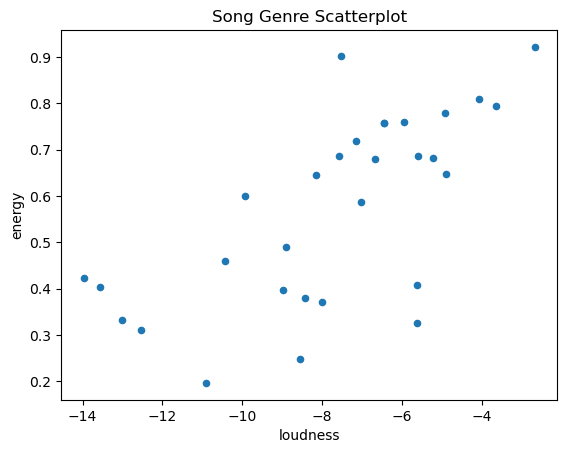

In [82]:
# Filter for the specific genre

genre_data_recs = recommendations[recommendations['track_genre'] == 'indie']  


# Create scatter plot with 'runtime' on x-axis and 'rating' on y-axis

genre_data_recs.plot.scatter(x='loudness', y='energy', title='Song Genre Scatterplot') 

I am going to try and make a better graph visual using plotly, but I think there is a correlation there and I would like to show it! 